# Este trabalho contém imagens fortes de feridas!

- Rafael Zaupa Watanabe
- 1941399

# Segmentação aproximada de feridas diabéticas via Deep Learning
No dataset:

- `DFU/Patches/Abnormal(Ulcer)`: patches 224×224 com úlceras
- `DFU/Patches/Normal(Healthy skin)`: patches 224×224 de pele saudável
- `DFU/Original Images`: imagens completas
- `DFU/TestSet`: imagens de teste

Como o dataset não traz máscaras pixel a pixel dos tecidos, o modelo abaixo faz uma **segmentação aproximada**!

O trabalho não foi desenvolvido com o intuito de realizar diagnóstico; a ideia é disponibilizar uma ferramenta auxiliar útil a pacientes e profissionais.

In [16]:
import os
import zipfile
import random
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow:', tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.20.0


In [17]:
# extrair o dataset do .zip do dataset que baixei do kaggle: https://www.kaggle.com/datasets/laithjj/diabetic-foot-ulcer-dfu
# nomeado "feridadiabetes.zip"
from google.colab import files

ZIP_PATH = Path('/content/feridadiabetes.zip')

if not ZIP_PATH.exists():
    print('Envie o arquivo feridadiabetes.zip')
    uploaded = files.upload()
    if len(uploaded) == 0:
        raise RuntimeError('Nenhum arquivo foi enviado.')
    ZIP_PATH = Path(next(iter(uploaded.keys())))

EXTRACT_DIR = Path('/content/dfu_dataset')
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

DATA_ROOT = EXTRACT_DIR / 'DFU'
print('Dataset extraído em:', DATA_ROOT)

for folder in [
    DATA_ROOT / 'Patches' / 'Abnormal(Ulcer)',
    DATA_ROOT / 'Patches' / 'Normal(Healthy skin)',
    DATA_ROOT / 'Original Images',
    DATA_ROOT / 'TestSet'
]:
    files_count = len([p for p in folder.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']])
    print(f'{folder}: {files_count} imagens')

Dataset extraído em: /content/dfu_dataset/DFU
/content/dfu_dataset/DFU/Patches/Abnormal(Ulcer): 512 imagens
/content/dfu_dataset/DFU/Patches/Normal(Healthy skin): 543 imagens
/content/dfu_dataset/DFU/Original Images: 493 imagens
/content/dfu_dataset/DFU/TestSet: 166 imagens


In [18]:
# dataset de treino
# classificação: 0 -> pele normal
#                1 -> pele ferida

ABNORMAL_DIR = DATA_ROOT / 'Patches' / 'Abnormal(Ulcer)'
NORMAL_DIR   = DATA_ROOT / 'Patches' / 'Normal(Healthy skin)'

IMG_EXTS = ['.jpg', '.jpeg', '.png', '.webp']

def list_images(folder):
    return sorted([str(p) for p in folder.glob('*') if p.suffix.lower() in IMG_EXTS])

abnormal_paths = list_images(ABNORMAL_DIR)
normal_paths = list_images(NORMAL_DIR)

records = []
for p in normal_paths:
    records.append({'path': p, 'label': 0, 'class_name': 'normal'})
for p in abnormal_paths:
    records.append({'path': p, 'label': 1, 'class_name': 'ulcer'})

df = pd.DataFrame(records)
print(df['class_name'].value_counts())
df.head()

class_name
normal    543
ulcer     512
Name: count, dtype: int64


,path,label,class_name
0,/content/dfu_dataset/DFU/Patches/Normal(Health...,0,normal
1,/content/dfu_dataset/DFU/Patches/Normal(Health...,0,normal
2,/content/dfu_dataset/DFU/Patches/Normal(Health...,0,normal
3,/content/dfu_dataset/DFU/Patches/Normal(Health...,0,normal
4,/content/dfu_dataset/DFU/Patches/Normal(Health...,0,normal


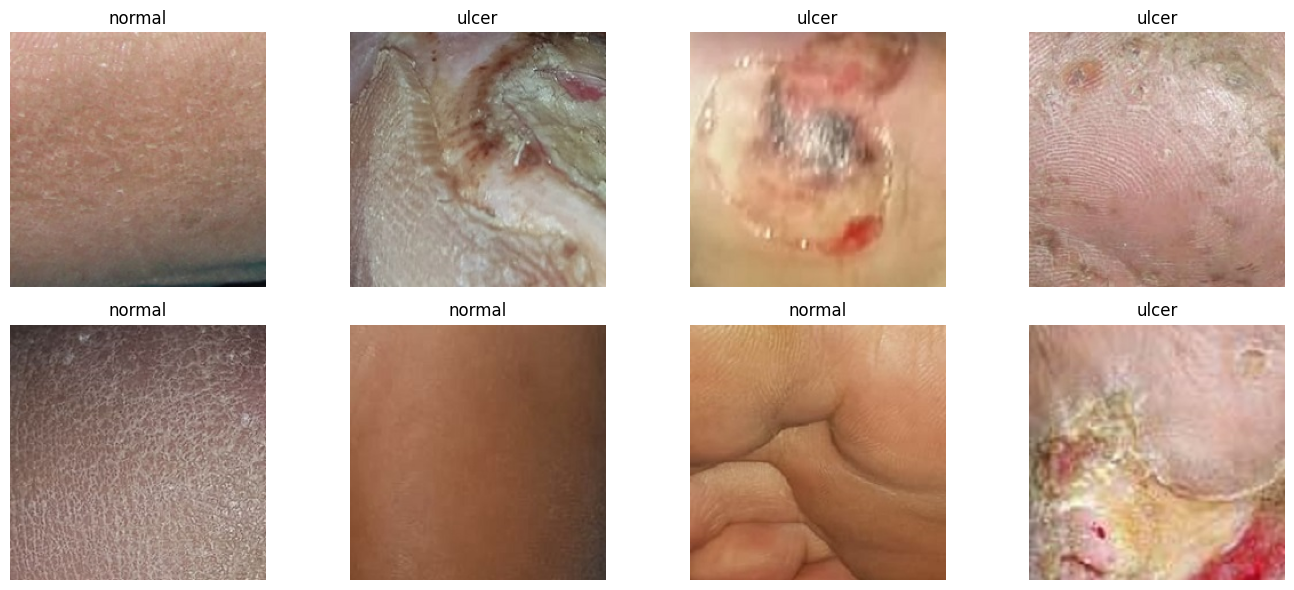

In [19]:
# exemplos aleatórios do dataset, pra ter uma noção de como são as imagens em geral
# varia com a seed, pra controlar.

def show_random_examples(df, n=8):
    sample = df.sample(n=n, random_state=SEED).reset_index(drop=True)
    plt.figure(figsize=(14, 6))
    for i, row in sample.iterrows():
        img = Image.open(row['path']).convert('RGB')
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.title(row['class_name'])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_random_examples(df, n=8)

In [20]:
# treino, validação, teste
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print('Treino:', len(train_df))
print('Validação:', len(val_df))
print('Teste:', len(test_df))
print('\nDistribuição no treino:')
print(train_df['class_name'].value_counts())

Treino: 738
Validação: 158
Teste: 159

Distribuição no treino:
class_name
normal    380
ulcer     358
Name: count, dtype: int64


In [21]:
# pipeline tf.data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# os patches ja tem 224x224, mas o resize reforça a dimensão
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)  # mantém faixa 0-255, o modelo normaliza internamente
    label = tf.cast(label, tf.float32)
    return image, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe['path'].values
    labels = dataframe['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)

In [22]:
# construindo CNN por transfer learning
# MobileNetV2
# 0 pele normal, 1 região de ferida

def build_model():
    inputs = keras.Input(shape=(224, 224, 3))

    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.10)(x)
    x = layers.RandomContrast(0.15)(x)

    # MobileNetV2 espera imagens na faixa [-1, 1].
    x = layers.Rescaling(scale=1./127.5, offset=-1)(x)

    base_model = keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
# treinamento do modelo

# melhor modelo salvo aqui caso precise referenciar
CHECKPOINT_PATH = '/content/best_dfu_patch_classifier.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping( # earlystopping => caso não apresente sinais que vai melhorar
        monitor='val_auc',
        mode='max',
        patience=6, # margem para o earlystopping
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30, # numero de epocas
    callbacks=callbacks
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5298 - auc: 0.5519 - loss: 0.8017 - precision: 0.4902 - recall: 0.6090
Epoch 1: val_auc improved from None to 0.67324, saving model to /content/best_dfu_patch_classifier.keras

Epoch 1: finished saving model to /content/best_dfu_patch_classifier.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 216ms/step - accuracy: 0.5352 - auc: 0.5642 - loss: 0.7746 - precision: 0.5177 - recall: 0.6117 - val_accuracy: 0.6266 - val_auc: 0.6732 - val_loss: 0.6505 - val_precision: 0.6000 - val_recall: 0.7013
Epoch 2/30
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6450 - auc: 0.6949 - loss: 0.6571 - precision: 0.6129 - recall: 0.7311
Epoch 2: val_auc improved from 0.67324 to 0.85706, saving model to /content/best_dfu_patch_classifier.keras

Epoch 2: finished saving model to /content/best_dfu_patch_classifier.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.6707 - auc: 0.7352 - loss: 0.6221 - precision: 0.6328 - recall: 0.7654 - val_

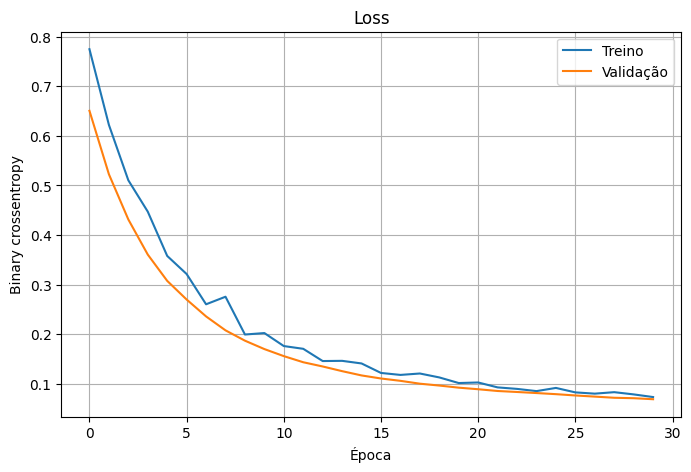

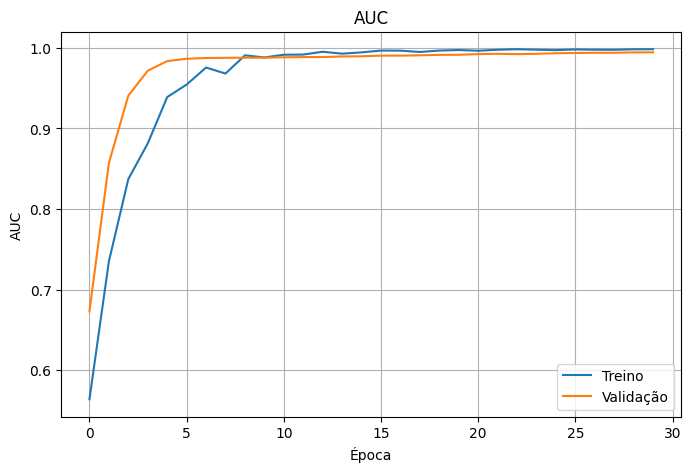

In [24]:
# plotagem das curvas de treinamento
#

def plot_history(history):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist['loss'], label='Treino')
    plt.plot(hist['val_loss'], label='Validação')
    plt.title('Loss')
    plt.xlabel('Época')
    plt.ylabel('Binary crossentropy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist['auc'], label='Treino')
    plt.plot(hist['val_auc'], label='Validação')
    plt.title('AUC')
    plt.xlabel('Época')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

{'loss': 0.05659911781549454, 'compile_metrics': 0.9874213933944702}
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99        82
       ulcer       1.00      0.97      0.99        77

    accuracy                           0.99       159
   macro avg       0.99      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159



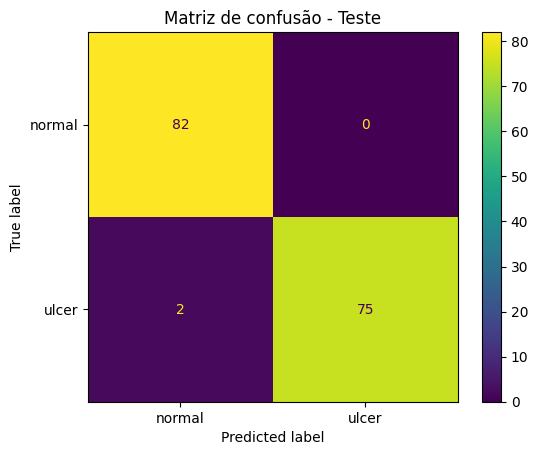

In [25]:
# avaliação no conjunto de teste

model = keras.models.load_model(CHECKPOINT_PATH)

results = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, results)))

probs = model.predict(test_ds).ravel()
y_true = test_df['label'].values.astype(int)
y_pred = (probs >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['normal', 'ulcer']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'ulcer'])
disp.plot(values_format='d')
plt.title('Matriz de confusão - Teste')
plt.show()

# Parte 2 — Segmentação aproximada em imagem completa

A ideia agora é aplicar o classificador de patches sobre uma imagem grande. Cada janela recebe uma probabilidade de conter ferida; ao juntar todas as janelas, obtemos um mapa de calor.

In [26]:
# funções auxiliares
def load_rgb_image(image_path):
    # carrega a imagem como RGB e corrige orientação EXIF se houver
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)
    img = img.convert('RGB')
    return np.array(img)


def resize_for_inference(rgb, target_patch=224, max_side=900):
    # redimensiona imagem para facilitar para a janela deslizante
    h, w = rgb.shape[:2]

    # garante que a menor dimensão tenha pelo menos target_patch
    if min(h, w) < target_patch:
        scale_up = target_patch / min(h, w)
        new_w = int(round(w * scale_up))
        new_h = int(round(h * scale_up))
        rgb = cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        h, w = rgb.shape[:2]

    # Limita a maior dimensão para evitar que fique lento demais
    if max(h, w) > max_side:
        scale_down = max_side / max(h, w)
        new_w = int(round(w * scale_down))
        new_h = int(round(h * scale_down))
        rgb = cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return rgb


def sliding_window_heatmap(image_path, model, patch_size=224, stride=32, batch_size=32, max_side=900):
    """
    geração do mapa de probabilidade de ferida usando janela deslizante
    stride menor aumenta resolução do mapa, mas deixa mais lento
    """
    rgb = load_rgb_image(image_path)
    rgb = resize_for_inference(rgb, target_patch=patch_size, max_side=max_side)
    h, w = rgb.shape[:2]

    ys = list(range(0, max(h - patch_size + 1, 1), stride))
    xs = list(range(0, max(w - patch_size + 1, 1), stride))

    if ys[-1] != h - patch_size:
        ys.append(h - patch_size)
    if xs[-1] != w - patch_size:
        xs.append(w - patch_size)

    coords = []
    patches = []

    for y in ys:
        for x in xs:
            crop = rgb[y:y+patch_size, x:x+patch_size]
            if crop.shape[0] != patch_size or crop.shape[1] != patch_size:
                continue
            coords.append((y, x))
            patches.append(crop.astype(np.float32))

    patches = np.array(patches, dtype=np.float32)
    probs = model.predict(patches, batch_size=batch_size, verbose=1).ravel()

    heat_sum = np.zeros((h, w), dtype=np.float32)
    heat_count = np.zeros((h, w), dtype=np.float32)

    for (y, x), p in zip(coords, probs):
        heat_sum[y:y+patch_size, x:x+patch_size] += p
        heat_count[y:y+patch_size, x:x+patch_size] += 1.0

    heatmap = heat_sum / np.maximum(heat_count, 1e-6)
    return rgb, heatmap


def postprocess_wound_mask(
    heatmap,
    threshold=0.80,
    keep_largest=True,
    blur_ksize=21,
    min_area=500
):
    """
    transforma o mapa de calor em uma máscara binária da ferida.

    adicionais:
    - suaviza o heatmap antes da limiarização
    - remove regiões pequenas
    - mantém apenas a maior região
    """

    # Suavização do mapa de probabilidade.
    # Isso reduz bordas muito quadradas e pequenas oscilações.
    if blur_ksize is not None and blur_ksize > 1:
        heatmap_proc = cv2.GaussianBlur(heatmap, (blur_ksize, blur_ksize), 0)
    else:
        heatmap_proc = heatmap.copy()

    # limiarização: pixels acima do threshold são considerados ferida
    mask = (heatmap_proc >= threshold).astype(np.uint8)

    # operações morfológicas pra limpar a máscara
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # remoção de componentes pequenos
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == i] = 1

    mask = cleaned

    # mantém apenas a maior região conectada
    # reduz falsos positivos espalhados na imagem
    if keep_largest:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

        if num_labels > 1:
            largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            mask = (labels == largest_label).astype(np.uint8)

    return mask


def overlay_mask(rgb, mask, color=(255, 0, 0), alpha=0.35):
    # sobrepõe a máscara na imagem RGB
    overlay = rgb.copy().astype(np.float32)
    color_arr = np.array(color, dtype=np.float32)
    overlay[mask.astype(bool)] = (1 - alpha) * overlay[mask.astype(bool)] + alpha * color_arr
    return np.clip(overlay, 0, 255).astype(np.uint8)


def show_wound_detection(rgb, heatmap, mask):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title('Imagem original')
    axes[0].axis('off')

    im = axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Mapa de probabilidade de ferida')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(overlay_mask(rgb, mask))
    axes[2].set_title('Máscara aproximada de ferida')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

Imagem usada: /content/dfu_dataset/DFU/TestSet/0.jpg
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


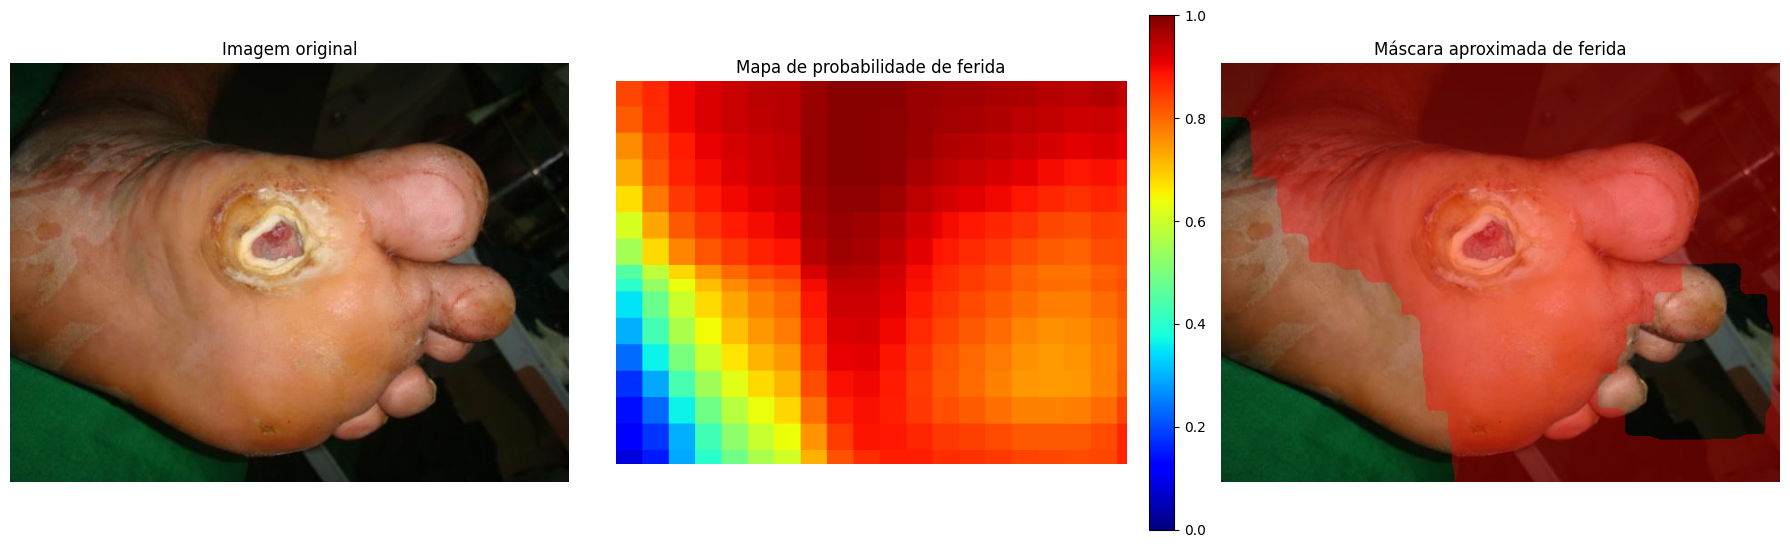

In [37]:
# teste em imagem do próprio dataset
candidate_images = sorted([
    str(p) for p in (DATA_ROOT / 'TestSet').glob('*')
    if p.suffix.lower() in IMG_EXTS
])

TEST_IMAGE_PATH = candidate_images[0]
print('Imagem usada:', TEST_IMAGE_PATH)

rgb, heatmap = sliding_window_heatmap(
    TEST_IMAGE_PATH,
    model,
    patch_size=224,
    stride=32,
    max_side=900
)

wound_mask = postprocess_wound_mask(
    heatmap,
    threshold=0.80,
    keep_largest=True,
    blur_ksize=21,
    min_area=500
)

show_wound_detection(rgb, heatmap, wound_mask)

Ajusto de `threshold`pode ajudar a melhorar a precisão.

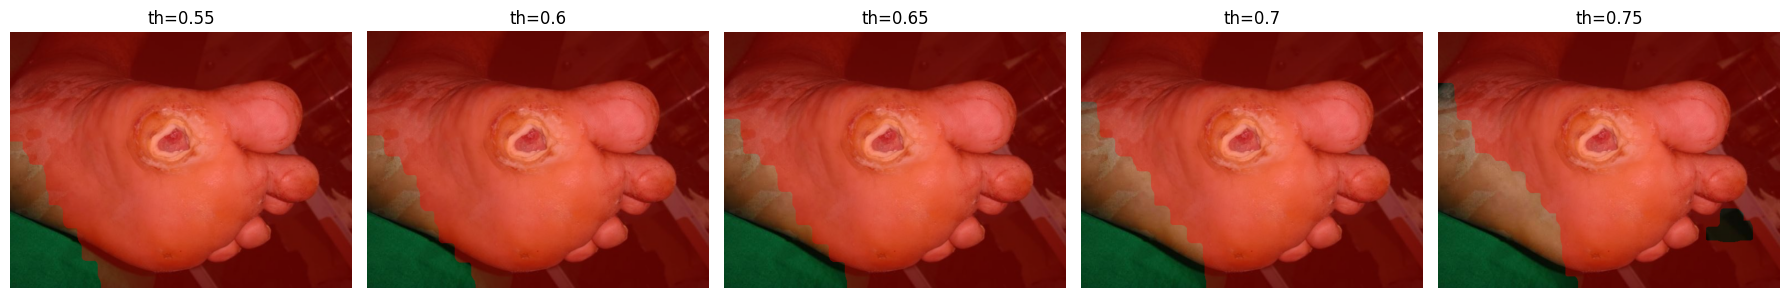

In [29]:
thresholds = [0.55, 0.60, 0.65, 0.70, 0.80]

plt.figure(figsize=(18, 8))

for i, th in enumerate(thresholds):
    mask_th = postprocess_wound_mask(
        heatmap,
        threshold=th,
        keep_largest=True,
        blur_ksize=21,
        min_area=500
    )

    vis = overlay_mask(rgb, mask_th)

    plt.subplot(1, len(thresholds), i+1)
    plt.imshow(vis)
    plt.title(f'th={th}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Parte 3 — Separação aproximada dos tecidos aparentes

Esta parte não é supervisionada pelo dataset, porque não existem máscaras de tipos de tecido. Portanto, ela usa regras de cor em HSV dentro da máscara provável de ferida. As classes são aproximadas e servem para fins acadêmicos:

- `fora_da_ferida`
- `escara_necrose_escura`
- `fibrina_slough`
- `granulacao`
- `epitelizacao`
- `maceracao`
- `incerto_na_ferida`

In [31]:
TISSUE_NAMES = {
    0: 'fora_da_ferida',
    1: 'escara_necrose_escura',
    2: 'fibrina_slough',
    3: 'granulacao',
    4: 'epitelizacao',
    5: 'maceracao',
    6: 'incerto_na_ferida'
}

TISSUE_COLORS = {
    1: (60, 60, 60),       # escara / necrose escura
    2: (255, 210, 0),      # fibrina / slough
    3: (220, 0, 0),        # granulação
    4: (255, 140, 180),    # epitelização
    5: (180, 220, 255),    # maceração
    6: (160, 160, 160)     # incerto
}


def remove_small_components(binary_mask, min_area=150):
    """
    remove pequenas regiões isoladas de uma máscara binária,
    isso evita vários pontinhos falsos nas classes de tecido
    que ocorreram durante testes de versões anteriores
    """

    binary_mask = binary_mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask,
        connectivity=8
    )

    cleaned = np.zeros_like(binary_mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned[labels == i] = 1

    return cleaned.astype(bool)


def get_inner_edge_band(mask, kernel_size=21):
    """
    criação de faixa interna próxima da borda da ferida.

    essa faixa é usada para limitar epitelização e maceração,
    que normalmente aparecem mais próximas das bordas da ferida
    """

    mask_uint = mask.astype(np.uint8)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded = cv2.erode(mask_uint, kernel, iterations=1)

    edge_band = (mask_uint == 1) & (eroded == 0)

    return edge_band


def classify_tissues_by_color(rgb, wound_mask, min_area=150):
    """
    classificação dos tecidos aparentes dentro da máscara da ferida

    Classes:
        0 = fora da ferida
        1 = escara / necrose escura
        2 = fibrina / slough
        3 = granulação
        4 = epitelização
        5 = maceração
        6 = incerto dentro da ferida
    """

    rgb = rgb.astype(np.uint8)
    wound_mask = wound_mask.astype(bool)

    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    tissue = np.zeros(wound_mask.shape, dtype=np.uint8)

    m = wound_mask

    # faixa interna próxima da borda da ferida
    edge_band = get_inner_edge_band(m, kernel_size=21)

    # 1 escara / necrose escura
    # detecta regiões muito escuras ou marrom-escuras
    necrosis = (
        (v < 65) |
        ((h >= 5) & (h <= 25) & (s > 30) & (v < 120))
    )

    # 2 Fibrina/slough
    # regiões amarelas, bege, castanho claro
    slough = (
        (h >= 15) & (h <= 45) &
        (s > 35) &
        (v > 70)
    )

    # 3 granulação
    # regiões vermelhas ou rosadas fortes
    red_hsv = (
        ((h <= 12) | (h >= 165)) &
        (s > 40) &
        (v > 60)
    )

    red_rgb = (
        (r > g + 15) &
        (r > b + 15)
    )

    granulation = red_hsv & red_rgb

    # 4 epitelização
    # tecido rosado claro ou branco perolado, principalmente próximo à borda interna da ferida.
    epithelial = (
        (r > 130) &
        (g > 80) &
        (b > 80) &
        (r >= g) &
        (r >= b) &
        (s < 95) &
        (v > 110) &
        edge_band
    )

    # 5 Maceração
    # regiões claras, pouco saturadas e esbranquiçadas, principalmente próximas às bordas.
    maceration = (
        (s < 45) &
        (v > 145) &
        edge_band
    )

    # aplica as classes apenas dentro da máscara da ferida e remove componentes muito pequenos
    necrosis = remove_small_components(necrosis & m, min_area=min_area)
    slough = remove_small_components(slough & m, min_area=min_area)
    granulation = remove_small_components(granulation & m, min_area=min_area)
    epithelial = remove_small_components(epithelial & m, min_area=min_area)
    maceration = remove_small_components(maceration & m, min_area=min_area)

    # ordem de prioridade;
    # a ordem importa porque algumas cores podem se sobrepor
    tissue[necrosis] = 1
    tissue[slough & (tissue == 0)] = 2
    tissue[granulation & (tissue == 0)] = 3
    tissue[epithelial & (tissue == 0)] = 4
    tissue[maceration & (tissue == 0)] = 5

    # o que sobrou dentro da ferida vira classe incerta
    tissue[m & (tissue == 0)] = 6

    # fora da ferida continua classe 0
    tissue[~m] = 0

    return tissue


def tissue_overlay(rgb, tissue, alpha=0.45):

    #Sobrepõe as cores das classes sobre a imagem original


    out = rgb.copy().astype(np.float32)

    for label, color in TISSUE_COLORS.items():
        mask = tissue == label

        if np.any(mask):
            color_arr = np.array(color, dtype=np.float32)
            out[mask] = (1 - alpha) * out[mask] + alpha * color_arr

    return np.clip(out, 0, 255).astype(np.uint8)


def tissue_percentages(tissue, wound_mask):

   # porcentagem de cada ferida dentro da máscara

    m = wound_mask.astype(bool)
    total = int(np.sum(m))

    rows = []

    if total == 0:
        return pd.DataFrame(columns=['classe', 'pixels', 'percentual'])

    for label in [1, 2, 3, 4, 5, 6]:
        count = int(np.sum(tissue[m] == label))

        rows.append({
            'classe': TISSUE_NAMES[label],
            'pixels': count,
            'percentual': 100 * count / total
        })

    return pd.DataFrame(rows).sort_values('percentual', ascending=False)


def show_tissue_segmentation(rgb, wound_mask, tissue):

    # Mostra:
    #1. imagem original
    #2. região provável da ferida
    #3. classificação dos tecidos aparentes

    overlay = tissue_overlay(rgb, tissue)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title('Imagem original')
    axes[0].axis('off')

    axes[1].imshow(overlay_mask(rgb, wound_mask))
    axes[1].set_title('Região provável de ferida')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Tecidos aparentes por cor')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    display(tissue_percentages(tissue, wound_mask))

## 16. Aplicar separação de tecidos na imagem testada

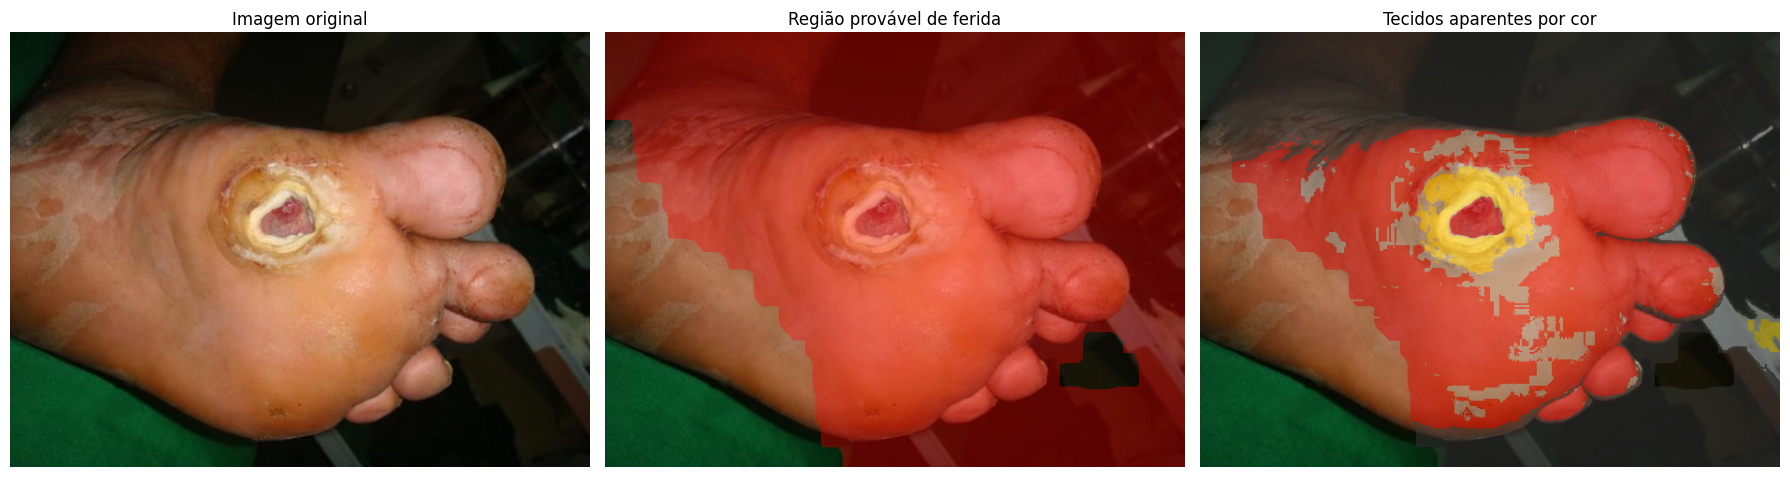

,classe,pixels,percentual
0,escara_necrose_escura,116475,50.484145
2,granulacao,86299,37.404861
5,incerto_na_ferida,19398,8.407739
1,fibrina_slough,8544,3.703254
3,epitelizacao,0,0.000000
4,maceracao,0,0.000000


In [32]:
tissue = classify_tissues_by_color(
    rgb,
    wound_mask,
    min_area=150
)

show_tissue_segmentation(rgb, wound_mask, tissue)

## Processamento de foto enviada pelo usuário

O paciente ou usuário envia uma foto, e o programa gera a região provável de ferida e a separação aproximada dos tecidos aparentes, igual aos exemplos.

Saving diabetic_foot_ulcer.jpg to diabetic_foot_ulcer (1).jpg
Imagem enviada: diabetic_foot_ulcer (1).jpg
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


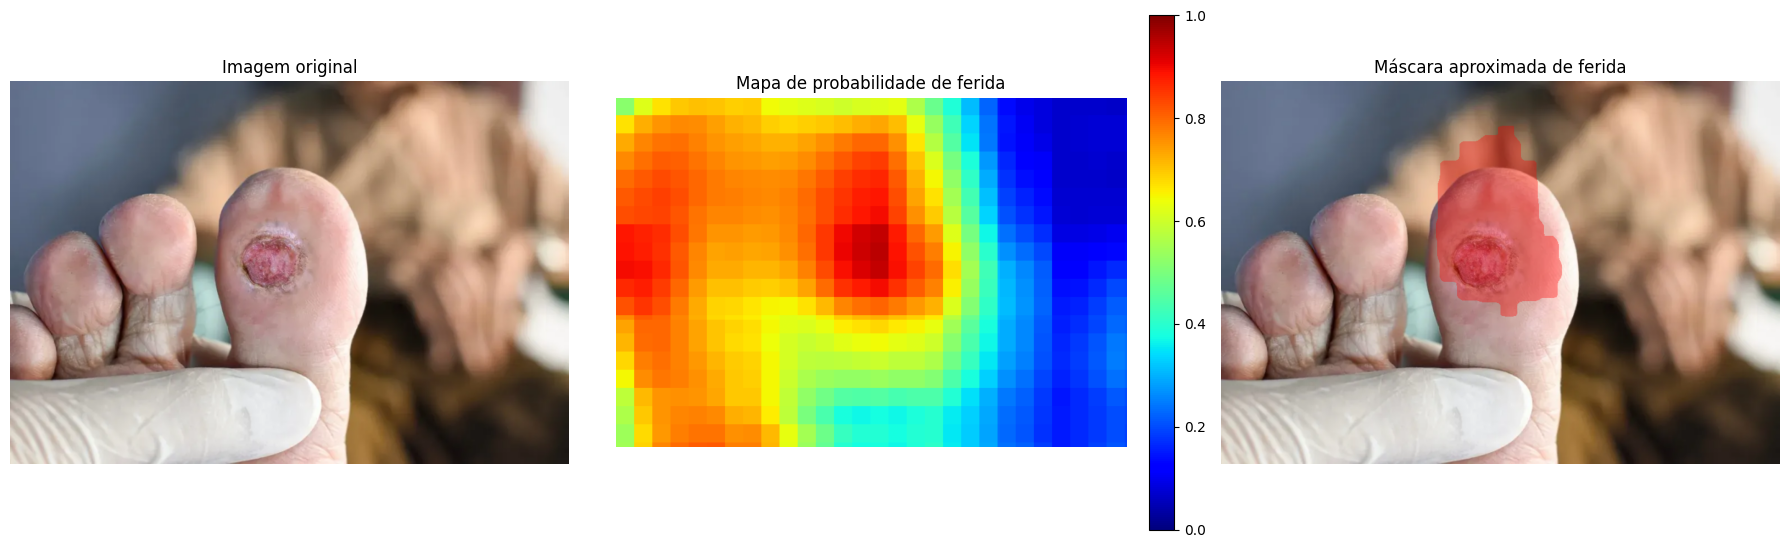

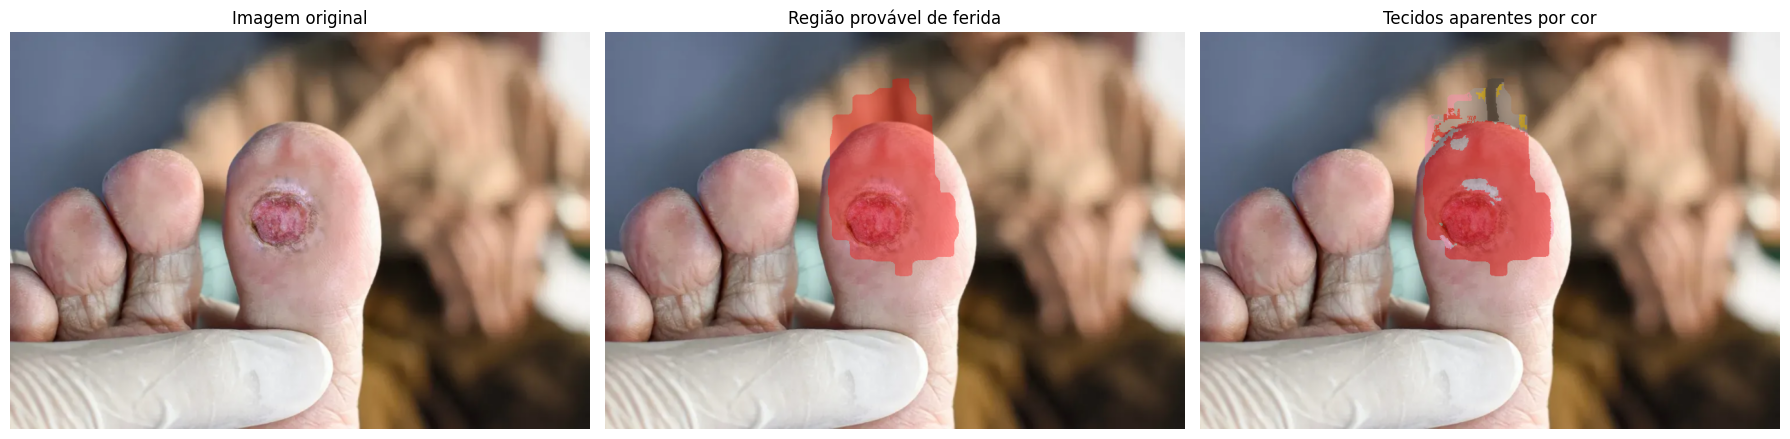

,classe,pixels,percentual
2,granulacao,34468,78.897613
5,incerto_na_ferida,6102,13.967542
3,epitelizacao,1545,3.536521
0,escara_necrose_escura,1140,2.609472
1,fibrina_slough,432,0.988853
4,maceracao,0,0.000000


In [36]:
from google.colab import files

uploaded = files.upload()
if len(uploaded) == 0:
    raise RuntimeError('Nenhuma imagem foi enviada.')

USER_IMAGE_PATH = next(iter(uploaded.keys()))
print('Imagem enviada:', USER_IMAGE_PATH)

user_rgb, user_heatmap = sliding_window_heatmap(
    USER_IMAGE_PATH,
    model,
    patch_size=224,
    stride=32,
    max_side=900
)

user_mask = postprocess_wound_mask(
    user_heatmap,
    threshold=0.80,
    keep_largest=True,
    blur_ksize=21,
    min_area=500
)

show_wound_detection(user_rgb, user_heatmap, user_mask)

user_tissue = classify_tissues_by_color(
    user_rgb,
    user_mask,
    min_area=150
)

show_tissue_segmentation(user_rgb, user_mask, user_tissue)

In [ ]:
# salva as imagens de saída
OUTPUT_DIR = Path('/content/resultados_dfu')
OUTPUT_DIR.mkdir(exist_ok=True)

# salva os resultados da última imagem do usuário, se ela foi processada, ou
# caso contrário, salva os resultados da imagem de teste
if 'user_rgb' in globals():
    save_rgb = user_rgb
    save_mask = user_mask
    save_tissue = user_tissue
    prefix = 'usuario'
else:
    save_rgb = rgb
    save_mask = wound_mask
    save_tissue = tissue
    prefix = 'teste'

mask_overlay = overlay_mask(save_rgb, save_mask)
tissue_vis = tissue_overlay(save_rgb, save_tissue)

Image.fromarray(mask_overlay).save(OUTPUT_DIR / f'{prefix}_mascara_ferida.png')
Image.fromarray(tissue_vis).save(OUTPUT_DIR / f'{prefix}_tecidos_aparentes.png')

print('Arquivos salvos em:', OUTPUT_DIR)
print(list(OUTPUT_DIR.glob('*')))

Arquivos salvos em: /content/resultados_dfu
[PosixPath('/content/resultados_dfu/usuario_tecidos_aparentes.png'), PosixPath('/content/resultados_dfu/usuario_mascara_ferida.png')]


Máscaras pixel a pixel seriam desenvolvidas por profissionais, e por isso, não é possível treinar uma U-Net ou DeepLabV3+ supervisionada para segmentar tecidos específicos, já que o dataset escolhido não possui.
O modelo treinado é um classificador binário de patches: pele normal versus ferida. A máscara final é obtida por janela deslizante, logo ela é aproximada e depende do limiar escolhido.
A separação entre as diferentes classificações é feita por regras de cor, não por aprendizado supervisionado. Para transformar este projeto em uma segmentação clínica real, seria necessário criar ou obter máscaras anotadas por especialistas.